In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc


In [3]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')
plt.rc('font', family='serif')

s_size = 5
latex_size = 20
scat = "scatter"
alp = 0.3
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams["xtick.minor.visible"] =  True
mpl.rcParams["ytick.minor.visible"] =  True
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['xtick.minor.width'] = 1.0

mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['ytick.minor.width'] = 1.0
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 1.5

mpl.rcParams.update({"axes.grid" : True, "grid.color": "black","grid.alpha": "0.3" })
mpl.rcParams['font.size'] = 16
plt.rc('legend', loc='best',fancybox=True,markerscale=2) 

In [4]:
# Read the data
data_files = [ 'CHWtill_hjj_big_data_data_aug.csv'
]
df_chw_hjj = pd.concat(
    [pd.read_csv(f) for f in data_files])
#df_chw_hjj.reset_index(drop=True, inplace=True)
print(df_chw_hjj.keys())

Index(['jet0Pt', 'jet0Eta', 'jet0Phi', 'jet1Pt', 'jet1Eta', 'jet1Phi', 'hPt',
       'hEta', 'hPhi', 'deltaphi', 'sign_w'],
      dtype='object')


In [5]:
df_chw_hjj

,jet0Pt,jet0Eta,jet0Phi,jet1Pt,jet1Eta,jet1Phi,hPt,hEta,hPhi,deltaphi,sign_w
0,1.672154,-1.843204,-2.729061,0.453930,2.680678,-2.133047,2.063609,-0.203925,0.536326,-0.596014,-1.0
1,0.838243,2.420060,0.634051,0.654418,-3.925637,-1.472383,0.755615,-3.366255,2.935448,2.106434,1.0
2,1.069747,-3.010563,2.193521,0.607195,3.378601,-2.764860,1.352552,2.252185,-0.497576,-1.324804,-1.0
3,0.955432,-1.819065,-2.268580,0.690238,2.735088,2.150509,1.003968,2.890846,0.154654,1.864097,1.0
4,1.739630,2.422367,2.142933,1.025206,-1.822045,0.927030,2.305829,1.977988,-1.428701,1.215903,1.0
...,...,...,...,...,...,...,...,...,...,...,...
307643,1.637737,2.061481,-1.836928,0.879578,-3.351331,2.667458,1.691415,-0.789086,0.770856,1.778800,1.0
307644,0.863166,-2.054948,-2.210073,0.528735,3.961637,1.956576,0.742186,0.297952,0.276821,2.116537,-1.0
307645,1.436319,0.445910,0.331807,0.763661,-2.707941,2.918419,0.884151,0.386789,-2.337280,-2.586612,-1.0
307646,0.768070,-2.647665,-2.000775,0.359936,0.542979,0.403940,0.556790,-0.378414,1.590189,-2.404715,-1.0


In [6]:
df_chw_hjj.jet0Phi - df_chw_hjj.jet1Phi

0        -0.596014
1         2.106434
2         4.958381
3        -4.419089
4         1.215903
            ...   
307643   -4.504385
307644   -4.166649
307645   -2.586612
307646   -2.404715
307647    1.623394
Length: 307648, dtype: float64

In [7]:
filtered_df = df_chw_hjj.dropna()
print(len(filtered_df), len(df_chw_hjj))

307648 307648


In [8]:

print(df_chw_hjj['sign_w'].unique())


[-1.  1.]


In [9]:
def plot_hist(df, column, weight=None, bins=30, xmin=None, xmax=None, label=None):
    data = df[column].values
    weights = df[weight].values if weight else None
    
    if xmin is None:
        xmin = data.min()
    if xmax is None:
        xmax = data.max()
    
    bin_edges = np.linspace(xmin, xmax, bins + 1)
    
    plt.hist(data, bins=bin_edges, weights=weights, 
             color='steelblue', 
             edgecolor='black',
             alpha=0.7,
             label=label)  # Add label here
    plt.xlabel(column)
    plt.ylabel('No. of Events')
    plt.grid(False)
    plt.tight_layout()
    if label:
        plt.legend()  # Show legend if label is provided
    return plt


In [10]:

def plot_diff_xsec(df, column, weight=None, bins=30, xmin=None, xmax=None):
    data = df[column].values
    weights = df[weight].values if weight else None
    
    # Determine range
    if xmin is None:
        xmin = data.min()
    if xmax is None:
        xmax = data.max()
    
    bin_edges = np.linspace(xmin, xmax, bins + 1)
    

    counts, _ = np.histogram(data, bins=bin_edges, weights=weights)
    
   
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    
    # Compute differential cross section: dσ/dX
    d_sigma = counts / bin_widths
    
    ## What is the total cross section and luminosity and eff.???

    # Normalize to unity
    total = np.sum(d_sigma * bin_widths)
    if total > 0:
        d_sigma /= total
    
    # Plot as bar chart
    plt.bar(bin_centers, d_sigma, width=bin_widths,
            color='steelblue', alpha=0.7)
    
    plt.xlabel(column)
    plt.ylabel(f'Normalized dσ/d{column} [fb/unit]')
    plt.grid(False)
    plt.tight_layout()
    
    return plt


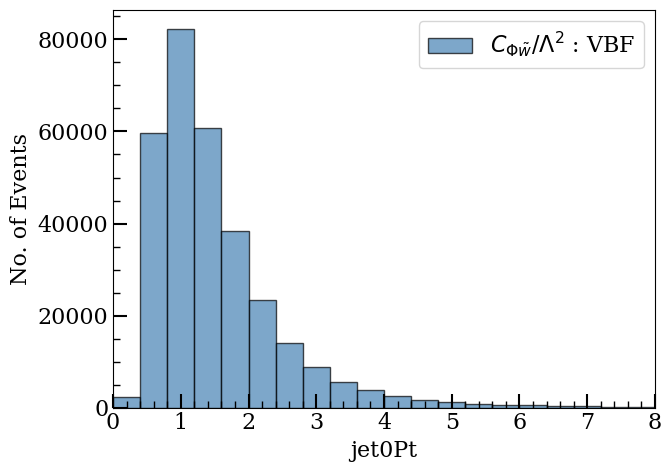

In [11]:
# 1. Basic histogram
plot_hist(df_chw_hjj, 'jet0Pt', bins=20, xmin=0.,xmax=8, label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')
#plot_hist(df_chw_hjj, 'jet1Pt', bins=20, xmin=0.,xmax=8, label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')

plt.show()

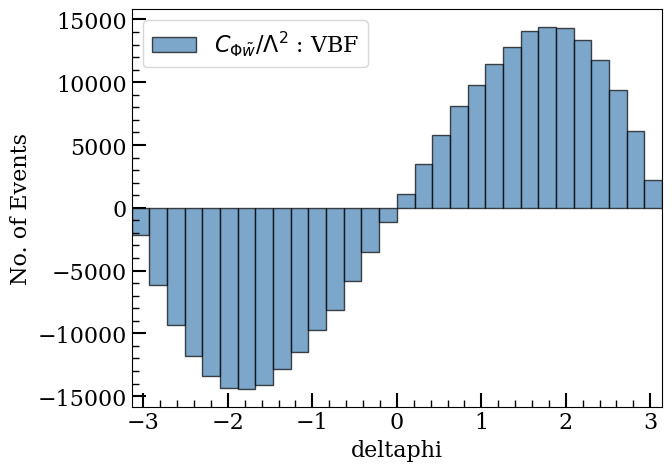

In [12]:
plot_hist(df_chw_hjj, 'deltaphi', bins=30, weight='sign_w', label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')
plt.show()
#plt.savefig('')


In [13]:
features = [
    'jet0Pt','jet0Eta','jet0Phi',
    'jet1Pt','jet1Eta','jet1Phi',
    'hPt','hEta','hPhi',
    'deltaphi'
]

X = df_chw_hjj[features].values
y = np.where(df_chw_hjj['sign_w'] > 0, 1, 0)  # + → 1, − → 0
weights = df_chw_hjj['sign_w'].values         # sign values as it is 
print(y)

[0 1 0 ... 0 0 1]


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [15]:
X

array([[ 0.15529056, -0.79598551, -1.50418174, ..., -0.12775528,
         0.29608254, -0.32853451],
       [-0.68012217,  1.04510001,  0.34947103, ..., -2.10889723,
         1.62053381,  1.16110738],
       [-0.44820123, -1.30010797,  1.2090071 , ...,  1.41095287,
        -0.27469038, -0.73025782],
       ...,
       [-0.0809693 ,  0.1925657 ,  0.18288271, ...,  0.24231645,
        -1.29031128, -1.42579086],
       [-0.75042135, -1.14339079, -1.10277059, ..., -0.23706943,
         0.87787457, -1.32552574],
       [ 0.52886507,  0.73987865,  0.03033322, ..., -0.43315602,
         1.65496404,  0.8948461 ]])

In [16]:
class VBFDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [17]:
dataset = VBFDataset(X, y)
loader = DataLoader(dataset, batch_size=256, shuffle=True)


Note: The interference term of SM and EFT is antisymmetric => odd upcer CP. tanh being an odd function performs better than ReLU 

In [18]:
class CPClassifier(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    #simple forward pass to all sequential layers until architectures like ResNets
    #(skip connections), transformers, or networks that change behavior during inference

    def forward(self, x):
        return self.net(x).squeeze()


In [19]:
device = torch.device("cpu")
model = CPClassifier(len(features))
print(model)


CPClassifier(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

epochs = 30


In [21]:
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch} | Loss {avg_loss:.5f}")



Epoch 0 | Loss 0.23937
Epoch 1 | Loss 0.20152
Epoch 2 | Loss 0.19472
Epoch 3 | Loss 0.19318
Epoch 4 | Loss 0.19281
Epoch 5 | Loss 0.19254
Epoch 6 | Loss 0.19224
Epoch 7 | Loss 0.19202
Epoch 8 | Loss 0.19193
Epoch 9 | Loss 0.19176
Epoch 10 | Loss 0.19162
Epoch 11 | Loss 0.19148
Epoch 12 | Loss 0.19132
Epoch 13 | Loss 0.19125
Epoch 14 | Loss 0.19120
Epoch 15 | Loss 0.19112
Epoch 16 | Loss 0.19106
Epoch 17 | Loss 0.19102
Epoch 18 | Loss 0.19103
Epoch 19 | Loss 0.19098
Epoch 20 | Loss 0.19099
Epoch 21 | Loss 0.19090
Epoch 22 | Loss 0.19088
Epoch 23 | Loss 0.19082
Epoch 24 | Loss 0.19080
Epoch 25 | Loss 0.19078
Epoch 26 | Loss 0.19076
Epoch 27 | Loss 0.19076
Epoch 28 | Loss 0.19073
Epoch 29 | Loss 0.19063


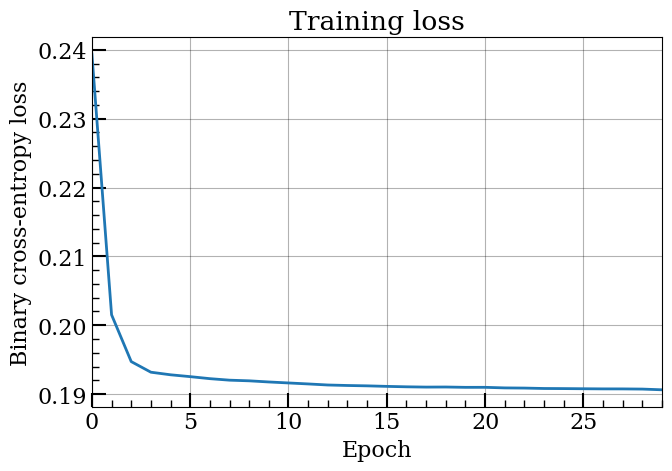

In [22]:

plt.plot(train_losses, lw=2)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Constructing the CP-odd observable

In [23]:
with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32)
    P_plus = model(X_tensor).numpy()

O_NN = 2.0 * P_plus - 1.0    # Same as Eq.(8) 


In [24]:
O_NN.min()

-0.9884343

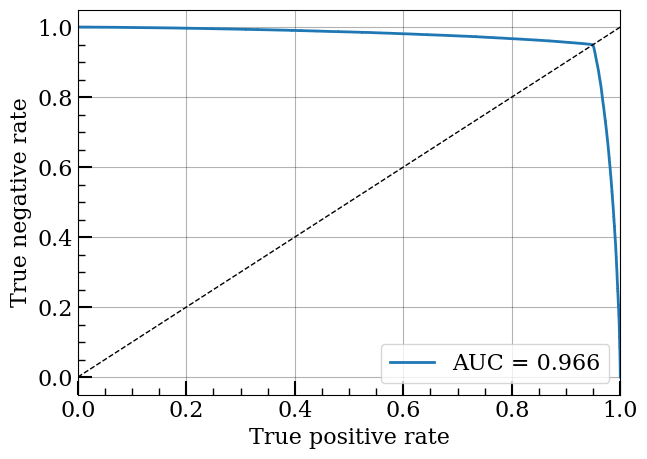

In [25]:
y_true = y
y_score = P_plus

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
plt.plot(tpr, 1 - fpr, lw=2,
         label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlabel("True positive rate")
plt.ylabel("True negative rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
def plot_ONN_distribution(O_NN, sign_w, bins=30):
    bin_edges = np.linspace(-1, 1, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    hist = np.zeros(bins)

    for i in range(bins):
        mask = (O_NN >= bin_edges[i]) & (O_NN < bin_edges[i+1])
        hist[i] = np.sum(sign_w[mask])   #weighted by interference sign

    plt.figure(figsize=(7,5))
    plt.bar(
        bin_centers,
        hist,
        width=bin_widths,
        color='steelblue',
        alpha=0.8
    )
    plt.axhline(0, color='black', lw=1)

    plt.xlabel(r'$O_{\rm NN}$')
    plt.ylabel(r'No. of Events')
    plt.title(r'ML-constructed CP-odd observable')
    plt.tight_layout()
    plt.show()


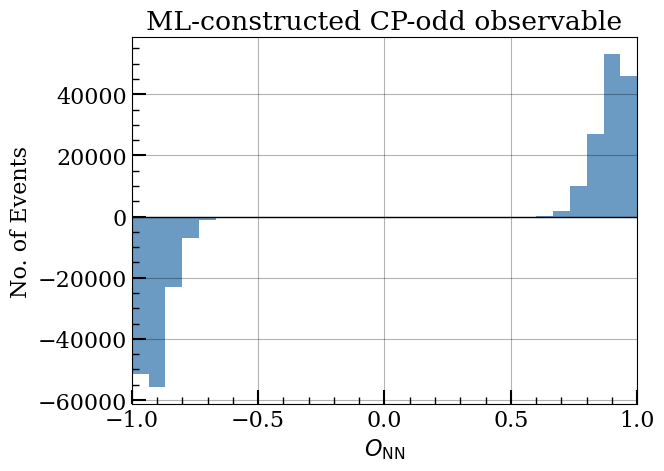

In [27]:
plot_ONN_distribution(O_NN, df_chw_hjj['sign_w'].values)

In [28]:
from IPython.display import Math
A_NN = np.mean(df_chw_hjj['sign_w'].values * O_NN)
A_trad = np.mean(df_chw_hjj['sign_w'].values * np.sin(df_chw_hjj['deltaphi'].values))

print(rf'Av. O_NN_CP: {A_NN}')
print(rf'Av Delta Phi: {A_trad}')



Av. O_NN_CP: 0.8094678820438864
Av Delta Phi: 0.698825728200129


## Symbolic Regression

PYSR: https://www.youtube.com/watch?v=q6tjKXmhiMs  Another 
https://www.youtube.com/watch?v=HKJB0Bjo6tQ <br>  Symbolic Models from Deep Learning
with Inductive Biases https://arxiv.org/pdf/2006.11287

In [ ]:
m_h = 125.0

df_chw_hjj['deltaeta'] = df_chw_hjj['jet0Eta'] -  df_chw_hjj['jet1Eta']

df_chw_hjj['xj0'] = df_chw_hjj['jet0Pt'] / m_h
df_chw_hjj['xj1'] = df_chw_hjj['jet1Pt'] / m_h


# inv mass calcualtion =============> mjj^2=2 pT0 pT1 (cosh(eta_0 − eta_1)  − cos(phi_0 - phi_1)) 

deta = df_chw_hjj['jet0Eta'] - df_chw_hjj['jet1Eta']
dphi = df_chw_hjj['jet0Phi'] - df_chw_hjj['jet1Phi']
dphi = (dphi + np.pi) % (2 * np.pi) - np.pi  # Wrap delta phi [-pi , + pi]

m2 = 2.0 * df_chw_hjj['jet0Pt'] * df_chw_hjj['jet1Pt'] * (np.cosh(deta) - np.cos(dphi))
df_chw_hjj['m_jj_1'] = np.sqrt(np.clip(m2, 0, None))


In [ ]:
import ROOT
def add_invariant_mass(df):
    m_jj_list = []
    for _, row in df.iterrows():
        # Create TLorentzVector for each jet (assuming massless)
        jet0 = ROOT.TLorentzVector()
        jet0.SetPtEtaPhiM(row['jet0Pt'], row['jet0Eta'], row['jet0Phi'], 0)

        jet1 = ROOT.TLorentzVector()
        jet1.SetPtEtaPhiM(row['jet1Pt'], row['jet1Eta'], row['jet1Phi'], 0)
        jj = jet0 + jet1
        m_jj_list.append(jj.M())
    df['m_jj'] = m_jj_list
    return df

# Apply to your DataFrame
df_chw_hjj = add_invariant_mass(df_chw_hjj)





In [38]:
df_chw_hjj

,jet0Pt,jet0Eta,jet0Phi,jet1Pt,jet1Eta,jet1Phi,hPt,hEta,hPhi,deltaphi,sign_w,deltaeta,xj0,xj1,m_jj,m_jj_1
0,1.672154,-1.843204,-2.729061,0.453930,2.680678,-2.133047,2.063609,-0.203925,0.536326,-0.596014,-1.0,-4.523882,0.013377,0.003631,8.290355,8.290355
1,0.838243,2.420060,0.634051,0.654418,-3.925637,-1.472383,0.755615,-3.366255,2.935448,2.106434,1.0,6.345697,0.006706,0.005235,17.699143,17.699143
2,1.069747,-3.010563,2.193521,0.607195,3.378601,-2.764860,1.352552,2.252185,-0.497576,-1.324804,-1.0,-6.389164,0.008558,0.004858,19.656987,19.656987
3,0.955432,-1.819065,-2.268580,0.690238,2.735088,2.150509,1.003968,2.890846,0.154654,1.864097,1.0,-4.554152,0.007643,0.005522,7.940763,7.940763
4,1.739630,2.422367,2.142933,1.025206,-1.822045,0.927030,2.305829,1.977988,-1.428701,1.215903,1.0,4.244412,0.013917,0.008202,11.095987,11.095987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307643,1.637737,2.061481,-1.836928,0.879578,-3.351331,2.667458,1.691415,-0.789086,0.770856,1.778800,1.0,5.412812,0.013102,0.007037,17.990380,17.990380
307644,0.863166,-2.054948,-2.210073,0.528735,3.961637,1.956576,0.742186,0.297952,0.276821,2.116537,-1.0,-6.016585,0.006905,0.004230,13.699389,13.699389
307645,1.436319,0.445910,0.331807,0.763661,-2.707941,2.918419,0.884151,0.386789,-2.337280,-2.586612,-1.0,3.153851,0.011491,0.006109,5.254183,5.254183
307646,0.768070,-2.647665,-2.000775,0.359936,0.542979,0.403940,0.556790,-0.378414,1.590189,-2.404715,-1.0,-3.190644,0.006145,0.002879,2.672048,2.672048


In [49]:
features_SR= ['jet0Pt','jet0Eta','jet0Phi',
              'jet1Pt','jet1Eta','jet1Phi',
              'hPt','hEta','hPhi',
              'deltaphi','deltaeta','m_jj']


X_SR = df_chw_hjj[features_SR].values
y_SR = np.where(df_chw_hjj['sign_w'] > 0, 1, 0)  # + → 1, − → 0
weights_SR = df_chw_hjj['sign_w'].values         # sign values as it is 
print(X_SR.shape, y_SR)

(307648, 12) [0 1 0 ... 0 0 1]


In [51]:
X_SR = scaler.fit_transform(X_SR)

In [52]:
class VBFDataset_SR(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [53]:
dataset_SR = VBFDataset_SR(X_SR, y_SR)
loader_SR = DataLoader(dataset_SR, batch_size=256, shuffle=True)


In [ ]:
# to do
# Prune the expression (keep 5–10 terms)
# Check CP antisymmetry numerically
# Test linearity vs c_h_wtilde
# Compare with sin delta phi jj

In [71]:
# -----------------------------
# Primitive function library g(z)
# -----------------------------
class PrimitiveLibrary(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, z):
        """
        z: (batch, m)
        returns phi: (batch, n_primitives)
        """
        B, m = z.shape
        feats = []
        # unary primitives
        feats.append(torch.sin(z))
        feats.append(torch.tanh(z))

        # binary primitives
        for i in range(m):
            for j in range(i + 1, m):
                feats.append((z[:, i] * z[:, j]).unsqueeze(1))
                feats.append((z[:, i] / (z[:, j] + self.eps)).unsqueeze(1)) #eps to avoide undef

        return torch.cat(feats, dim=1)
    

In [72]:
## to check the PrimitiveLibrary



batch_size = 4
m = 3   # number of latent coordinates

z = torch.randn(batch_size, m)
'''
sin(z) -> 3 ft, tanh(z) -> 3 ft
for (0,1), (0,2), (1,2) -> 3 pairs ; * & / 2 per pair ==> 6 ft 
Total ft (3 + 3 + 6) =12
'''

plib = PrimitiveLibrary()

phi = plib(z)

print("z shape:", z.shape)
print("phi shape:", phi.shape)
print("phi:", phi)


z shape: torch.Size([4, 3])
phi shape: torch.Size([4, 12])
phi: tensor([[ 0.2436,  0.0490, -0.4315,  0.2413,  0.0490, -0.4188,  0.0121,  5.0212,
         -0.1098, -0.5516, -0.0219, -0.1098],
        [-0.7598, -0.9180,  0.6667, -0.6978, -0.8220,  0.6229,  1.0036,  0.7420,
         -0.6297, -1.1826, -0.8487, -1.5937],
        [ 0.1942,  0.4207,  0.5949,  0.1930,  0.4089,  0.5629,  0.0849,  0.4500,
          0.1245,  0.3067,  0.2767,  0.6816],
        [-0.9226, -0.1322, -0.7131, -0.8258, -0.1318, -0.9819,  0.1557,  8.8638,
          2.7583,  0.5004,  0.3112,  0.0565]])


In [73]:

# -----------------------------
# One symbolic layer
# z = W h + b
# phi = g(z)
# h = A phi
# -----------------------------

class SymbolicLayer(nn.Module):
    def __init__(self, in_dim, z_dim):
        super().__init__()
        # Linear mixing: z = W h + b
        self.linear = nn.Linear(in_dim, z_dim)

        # Primitive library g(z)
        self.primitives = PrimitiveLibrary()
        
        # Sparce symbolic combination
        # sin(z), tanh(z) → 2m
        # z_i z_j, z_i / z_j → m(m-1)
        n_primitives = 2 * z_dim + z_dim * (z_dim - 1)
        self.A = nn.Linear(n_primitives, z_dim, bias=False)

    def forward(self, h):
        z = self.linear(h)
        phi = self.primitives(z)
        h_next = self.A(phi)
        return h_next

    def l1_penalty(self):
        return torch.norm(self.A.weight, p=1)



In [75]:

# -----------------------------
# Full symbolic network
# -----------------------------

class SymbolicNetwork(nn.Module):
    def __init__(self, input_dim, z_dim=6, depth=1):
        super().__init__()

        layers = []
        in_dim = input_dim
        for _ in range(depth):
            layers.append(SymbolicLayer(in_dim, z_dim))
            in_dim = z_dim

        self.layers = nn.ModuleList(layers)
        self.output = nn.Linear(z_dim, 1)

    def forward(self, x):
        h = x
        for layer in self.layers:
            h = layer(h)

        f_theta = self.output(h)
        return torch.sigmoid(f_theta).squeeze()



    def sparsity_loss(self):
        return sum(layer.l1_penalty() for layer in self.layers)


In [76]:
# Model
model = SymbolicNetwork(
        input_dim=len(features_SR),
        z_dim=5,
        depth=1
    )

print(model)

SymbolicNetwork(
  (layers): ModuleList(
    (0): SymbolicLayer(
      (linear): Linear(in_features=12, out_features=5, bias=True)
      (primitives): PrimitiveLibrary()
      (A): Linear(in_features=30, out_features=5, bias=False)
    )
  )
  (output): Linear(in_features=5, out_features=1, bias=True)
)


In [79]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()
lambda_sparsity = 1e-3

# Training loop
epochs = 2
for epoch in range(epochs):
        total_loss = 0.0
        for xb, yb in loader_SR:
            optimizer.zero_grad()

            p_hat = model(xb)
            loss = criterion(p_hat, yb)
            loss = loss + lambda_sparsity * model.sparsity_loss()

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch:02d} | Loss {total_loss/len(loader):.4f}")
        
with torch.no_grad():
    X_torch = torch.tensor(X[:5], dtype=torch.float32)
    p = model(X_torch)
    print("Example probabilities:", p)



Epoch 00 | Loss 0.2663
Epoch 01 | Loss 0.2788
Example probabilities: tensor([0.0839, 0.9870, 0.0096, 0.9683, 0.9816])


In [80]:
model.eval()

SymbolicNetwork(
  (layers): ModuleList(
    (0): SymbolicLayer(
      (linear): Linear(in_features=12, out_features=5, bias=True)
      (primitives): PrimitiveLibrary()
      (A): Linear(in_features=30, out_features=5, bias=False)
    )
  )
  (output): Linear(in_features=5, out_features=1, bias=True)
)

In [82]:
def extract_symbolic_expression(model, feature_names, thresh=1e-3):
    model.eval()

    layer = model.layers[0]

    W = layer.linear.weight.detach().cpu().numpy()
    b = layer.linear.bias.detach().cpu().numpy()
    A = layer.A.weight.detach().cpu().numpy()
    w_out = model.output.weight.detach().cpu().numpy().flatten()
    b_out = model.output.bias.detach().cpu().numpy()[0]

    z_dim = W.shape[0]

    # ---- z_i definitions ----
    z_defs = []
    for i in range(z_dim):
        terms = [
            f"{W[i,j]:+.3f}*{feature_names[j]}"
            for j in range(len(feature_names)) if abs(W[i,j]) > thresh
        ]
        if abs(b[i]) > thresh:
            terms.append(f"{b[i]:+.3f}")
        z_defs.append(" ".join(terms))

    # ---- primitive labels ----
    prim_labels = []
    for i in range(z_dim):
        prim_labels.append(f"sin(z{i})")
    for i in range(z_dim):
        prim_labels.append(f"tanh(z{i})")
    for i in range(z_dim):
        for j in range(i+1, z_dim):
            prim_labels.append(f"(z{i}*z{j})")
            prim_labels.append(f"(z{i}/z{j})")

    # ---- hidden expressions ----
    h_defs = []
    for k in range(z_dim):
        terms = [
            f"{A[k,j]:+.3f}*{prim_labels[j]}"
            for j in range(len(prim_labels)) if abs(A[k,j]) > thresh
        ]
        h_defs.append(" ".join(terms))

    # ---- final expression ----
    print("\n=== Learned symbolic expression ===\n")
    for k in range(z_dim):
        if abs(w_out[k]) > thresh:
            print(f"{w_out[k]:+.3f} * ({h_defs[k]})")
    print(f"{b_out:+.3f}")

    print("\n=== Latent variables ===\n")
    for i, expr in enumerate(z_defs):
        print(f"z{i} = {expr}")


In [83]:

extract_symbolic_expression(model, features_SR)


=== Learned symbolic expression ===

-0.123 * (-0.029*tanh(z0) -0.076*(z0/z1) -0.024*(z0/z2) +0.002*(z0*z3) +0.085*(z0/z3) -0.107*(z0/z4) +0.144*(z1/z2) -0.002*(z1*z3) +0.002*(z1/z3) +0.032*(z1/z4) +0.002*(z2*z3) -0.101*(z2/z3) +0.002*(z2*z4) -0.059*(z2/z4) +0.002*(z3*z4) -0.033*(z3/z4))
-0.275 * (-1.307*sin(z0) +0.003*sin(z2) -0.004*sin(z4) -2.095*tanh(z0) +0.003*tanh(z2) -0.002*tanh(z4) +0.011*(z0*z1) +0.142*(z0/z1) +0.110*(z0*z2) +0.013*(z0/z2) +0.003*(z0*z3) +0.026*(z0/z3) -0.046*(z0*z4) +0.067*(z0/z4) -0.055*(z1/z2) -0.001*(z1*z3) -0.024*(z1/z3) +0.030*(z1/z4) -0.067*(z2/z3) +0.008*(z2/z4) -0.001*(z3*z4) -0.152*(z3/z4))
+0.159 * (+0.001*sin(z0) +0.512*tanh(z0) +0.137*(z0/z1) -0.002*(z0*z2) +0.019*(z0/z2) -0.002*(z0*z3) +0.089*(z0/z3) +0.044*(z0/z4) -0.003*(z1/z2) +0.002*(z1*z3) -0.108*(z1/z3) -0.015*(z1/z4) -0.002*(z2*z3) -0.012*(z2/z3) -0.002*(z2*z4) +0.008*(z2/z4) -0.002*(z3*z4) +0.024*(z3/z4))
+0.327 * (+1.627*sin(z0) -0.002*sin(z2) +0.003*sin(z3) +0.005*sin(z4) +2.482*tanh(z0

In [89]:
with torch.no_grad():
    X_tensor_SR = torch.tensor(X_SR, dtype=torch.float32)
    P_plus_SR = model(X_tensor_SR).numpy()

O_NN_SR = 2.0 * P_plus_SR - 1.0    # Same as Eq.(8) 


In [90]:
O_NN_SR

array([-0.7154367 ,  0.9321158 , -0.90889895, ..., -0.8399692 ,
       -0.89094174,  0.9408581 ], dtype=float32)

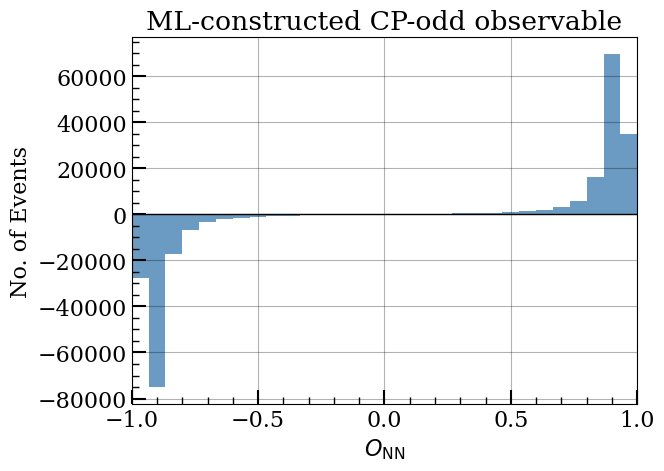

In [91]:
plot_ONN_distribution(O_NN_SR, df_chw_hjj['sign_w'].values)